In [1]:
try:
    from google.colab import drive
    drive.mount('/gdrive')
    dataset_root = '/gdrive/MyDrive/datasets'
    !pip install torchinfo tqdm
    colab = True
except Exception as e:
    print(e)
    print('Assuming we\'re not on colab.')
    dataset_root = './datasets'

print('Will store datasets in', dataset_root)

import os

if os.name == 'nt':
    print("Disabling multiprocessing because we're running on windows.")
    cpu_num = 0
elif colab:
    cpu_num = 2
else:
    cpu_num = os.cpu_count() // 2
    print('Dataloaders will use {} CPUs'.format(cpu_num))

No module named 'google'
Assuming we're not on colab.
Will store datasets in ./datasets
Disabling multiprocessing because we're running on windows.


In [2]:
import torch
import torch.utils.data as tud
import torch.nn as nn
import torch.nn.functional as F

import torchvision.transforms.functional as tvf
import torchvision.datasets as tds
import torchvision.utils as tu

from tqdm import tqdm
import matplotlib.pyplot as plt

In [3]:
mnist_train = tds.FashionMNIST(
    root=dataset_root,
    download=True,
    train=True,
    transform=tvf.pil_to_tensor,
)

mnist_eval = tds.FashionMNIST(
    root=dataset_root,
    download=True,
    train=False,
    transform=tvf.pil_to_tensor,
)

In [4]:
batchsize = 32

train_loader = tud.DataLoader(mnist_train, batch_size=batchsize, num_workers=cpu_num, shuffle=True)
val_loader = tud.DataLoader(mnist_eval, batch_size=batchsize, shuffle=True)

In [5]:
class MyNn(nn.Module):
    def __init__(self, in_sz, out_sz, hidden_sz=128):
        super().__init__()
        self.in_sz = in_sz
        self.out_sz = out_sz
        self.lin1 = nn.Linear(in_sz, hidden_sz, bias=True)
        self.lin2 = nn.Linear(hidden_sz, hidden_sz, bias=True)
        self.lin3 = nn.Linear(hidden_sz, hidden_sz, bias=True)
        self.lin4 = nn.Linear(hidden_sz, out_sz, bias=True)

    def forward(self, x):
        x = x.view(-1, self.in_sz)
        x = self.lin1(x)
        x = F.relu(x)
        x = self.lin2(x)
        x = F.relu(x)
        x = self.lin3(x)
        x = F.relu(x)
        x = self.lin4(x)
        return x

In [6]:
class MyCnn(nn.Module):
    def __init__(self, out_sz, ch=32):
        super().__init__()

        self.channels = ch
        self.out_sz = out_sz
        # (28x28)
        self.conv1_1 = nn.Conv2d(1, ch, kernel_size=3, stride=1, padding=1)
        self.conv1_2 = nn.Conv2d(ch, ch*2, kernel_size=3, stride=1, padding=1)

        # (14x14)
        self.lin1 = nn.Linear(ch*2 * 14 * 14, 128, bias=True)
        self.lin2 = nn.Linear(128, out_sz, bias=True)

    def forward(self, x):
        x = self.conv1_1(x)
        x = F.relu(x)
        x = self.conv1_2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, kernel_size=2)

        x = x.view(-1, self.channels*2 * 14 * 14)
        x = self.lin1(x)
        x = F.relu(x)
        x = self.lin2(x)
        return x

In [7]:
from torchinfo import summary
testmodel = MyNn(28 * 28, 10, hidden_sz=512)
# testmodel = MyCnn(out_sz=10, ch=32)
test = mnist_train[0][0].float()
target = mnist_train[0][1]
print(target, testmodel(test))
summary(testmodel, (1, 1, 28, 28))

9 tensor([[ 2.2365, -0.7373,  1.2860,  1.1645,  4.3092, -2.0177, -0.9748, -6.0803,
         -6.7969, -0.5154]], grad_fn=<AddmmBackward0>)


Layer (type:depth-idx)                   Output Shape              Param #
MyNn                                     [1, 10]                   --
├─Linear: 1-1                            [1, 512]                  401,920
├─Linear: 1-2                            [1, 512]                  262,656
├─Linear: 1-3                            [1, 512]                  262,656
├─Linear: 1-4                            [1, 10]                   5,130
Total params: 932,362
Trainable params: 932,362
Non-trainable params: 0
Total mult-adds (M): 0.93
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 3.73
Estimated Total Size (MB): 3.75

 10%|████████▎                                                                          | 1/10 [00:09<01:26,  9.64s/it]

0.4973967969417572


 20%|████████████████▌                                                                  | 2/10 [00:19<01:15,  9.48s/it]

0.44565361738204956


 30%|████████████████████████▉                                                          | 3/10 [00:28<01:06,  9.45s/it]

...

0.38345250487327576


 90%|██████████████████████████████████████████████████████████████████████████▋        | 9/10 [01:24<00:09,  9.37s/it]

0.36918315291404724


100%|██████████████████████████████████████████████████████████████████████████████████| 10/10 [01:33<00:00,  9.36s/it]

0.3862730860710144
CPU times: total: 49.5 s
Wall time: 1min 33s


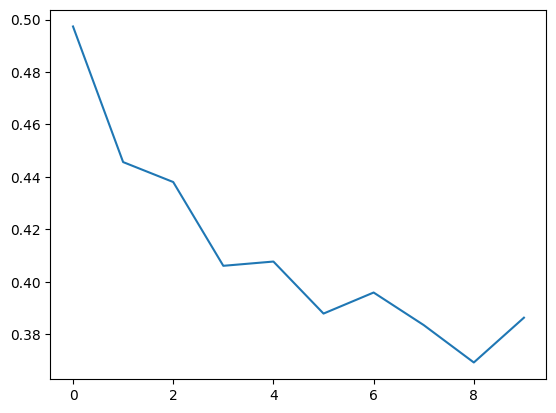

In [8]:
%%time
device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = MyNn(28 * 28, 10, hidden_sz=64).to(device)
# model = MyCnn(out_sz=10, ch=32).to(device)

optimizer = torch.optim.SGD(model.parameters(), lr=0.001)
lossfn = nn.CrossEntropyLoss()
epochs = 10

loss_plot = []
for epoch in tqdm(range(epochs)):
    for i, (images, target) in enumerate(train_loader):
        optimizer.zero_grad()
        images = images.float().to(device)
        targets = target.to(device)

        outs = model(images)
        loss = lossfn(outs, targets)
        loss.backward()
        optimizer.step()

    losses = []
    for i, (images, target) in enumerate(val_loader):
        with torch.no_grad():
            images = images.float().to(device)
            targets = target.to(device)
            outs = model(images)
            loss = lossfn(outs, targets)
            losses.append(loss)
    epoch_loss = torch.Tensor(losses).mean().item()
    print(epoch_loss)
    loss_plot.append(epoch_loss)

plt.plot(loss_plot)

In [10]:
total = len(mnist_eval)
correct = 0
with torch.no_grad():
    for image, target in mnist_eval:
        pred = model(image.float().to(device))
        pred = F.softmax(pred, dim=1).argmax()
        if pred == target:
            correct += 1
        
    print("{:.2f}% correct".format(100*correct/total))

86.14% correct


In [11]:
from ipywidgets import interact

classes = {
    0:  "T-shirt/top",
    1: 	"Trouser",
    2: 	"Pullover",
    3: 	"Dress",
    4: 	"Coat",
    5: 	"Sandal",
    6: 	"Shirt",
    7: 	"Sneaker",
    8: 	"Bag",
    9: 	"Ankle boot",
}

@interact(index=(0, len(mnist_eval) - 1, 1))
def draw_preds(index=0):
    with torch.no_grad():
        image = mnist_eval[index][0]
        pred = model(image.float().to(device))
        pred = F.softmax(pred, dim=1)
        clsid = pred.argmax()
        plt.imshow(image.float().cpu().squeeze(), cmap='gray')
        print(classes[int(clsid)])

interactive(children=(IntSlider(value=0, description='index', max=9999), Output()), _dom_classes=('widget-inte…